# Rossby Number Computation

Computes empirical convective turnover times (τ_cE, τ_cE_err) and Rossby numbers (Ro = P_rot / τ_cE) for all stars in:
- `cf_data/training_stars.csv`
- `cf_data/test_stars.csv` (renamed from validation_stars.csv)
- `cf_data/mmcoeval.csv`

τ_cE and τ_cE_err are linearly interpolated as a function of stellar mass from Table 2 of Gossage et al. (2024),
which empirically derived turnover times for 0.18–1.09 M☉ using X-ray/rotation data.

**Pre-processing steps also performed here:**
- Drop LHS 1376 & LHS 1377 from mmcoeval (see note in Notion)
- Add `high_ruwe` flag (ruwe ≥ 1.2) to test_stars and mmcoeval

In [1]:
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

DATA_DIR = 'cf_data/'

## Gossage (2024) Table 2 — Empirical Convective Turnover Times

14 mass bins covering 0.18–1.09 M☉. Mass values are the **median mass within each bin**
(standard deviation ≈ 0.03 M☉, not used). τ_cE uncertainties are 1σ from the MCMC posterior.

Note the non-monotonic peak at ~0.30 M☉ — the sharp rise in τ_cE at the fully convective boundary.

In [2]:
# Gossage (2024) Table 2 — transcribed exactly from the paper
# mass_msun: median mass within each bin [M☉]
# tau_ce:    empirical convective turnover time [days]
# tau_ce_err: 1σ uncertainty on tau_ce [days]
# n:         number of stars in the bin

gossage_table2 = pd.DataFrame({
    'mass_msun':   [0.18, 0.22, 0.30, 0.38, 0.43, 0.53, 0.60, 0.67, 0.73, 0.81, 0.89, 0.96, 1.01, 1.09],
    'tau_ce':      [214.59, 203.91, 239.77, 135.36, 81.54, 64.29, 43.61, 36.77, 32.49, 23.95, 19.49, 14.58, 10.96, 7.46],
    'tau_ce_err':  [30.90,  38.73,  49.66,  10.04,  5.96,  4.71,  2.50,  1.79,  1.64,  1.26,  0.73,  0.53,  0.41, 0.42],
    'n':           [46, 99, 89, 127, 119, 101, 128, 162, 133, 141, 208, 194, 176, 90],
})

print('Gossage (2024) Table 2 — cross-verify against paper:')
print(gossage_table2.to_string(index=False))

Gossage (2024) Table 2 — cross-verify against paper:
 mass_msun  tau_ce  tau_ce_err   n
      0.18  214.59       30.90  46
      0.22  203.91       38.73  99
      0.30  239.77       49.66  89
      0.38  135.36       10.04 127
      0.43   81.54        5.96 119
      0.53   64.29        4.71 101
      0.60   43.61        2.50 128
      0.67   36.77        1.79 162
      0.73   32.49        1.64 133
      0.81   23.95        1.26 141
      0.89   19.49        0.73 208
      0.96   14.58        0.53 194
      1.01   10.96        0.41 176
      1.09    7.46        0.42  90


## Build Linear Interpolator

Linear interpolation in mass space between the 14 bin-center points.

Stars outside [0.18, 1.09] M☉ use constant boundary extrapolation:
- Below 0.18 M☉ → τ_cE = 214.59 days (the 0.18 M☉ boundary value). These are fully convective stars where τ_cE is already roughly flat and high; extending the slope downward would give physically wrong decreasing τ_cE.
- Above 1.09 M☉ → τ_cE = 7.46 days (no stars currently above this limit, included for completeness).

In [3]:
tau_ce_boundary_lo = gossage_table2['tau_ce'].iloc[0]       # 214.59 days at 0.18 M☉
tau_ce_boundary_hi = gossage_table2['tau_ce'].iloc[-1]      # 7.46 days at 1.09 M☉
tau_ce_err_boundary_lo = gossage_table2['tau_ce_err'].iloc[0]   # 30.90 days at 0.18 M☉
tau_ce_err_boundary_hi = gossage_table2['tau_ce_err'].iloc[-1]  # 0.42 days at 1.09 M☉

tau_ce_interp = interp1d(
    gossage_table2['mass_msun'],
    gossage_table2['tau_ce'],
    kind='linear',
    bounds_error=False,
    fill_value=(tau_ce_boundary_lo, tau_ce_boundary_hi),
)

tau_ce_err_interp = interp1d(
    gossage_table2['mass_msun'],
    gossage_table2['tau_ce_err'],
    kind='linear',
    bounds_error=False,
    fill_value=(tau_ce_err_boundary_lo, tau_ce_err_boundary_hi),
)

# Sanity check
residuals = tau_ce_interp(gossage_table2['mass_msun']) - gossage_table2['tau_ce'].values
assert np.allclose(residuals, 0), 'Interpolator does not reproduce table values exactly'
print(f'tau_ce  boundary: below 0.18 M☉ → {tau_ce_boundary_lo} days, above 1.09 M☉ → {tau_ce_boundary_hi} days')
print(f'tau_ce_err boundary: below 0.18 M☉ → {tau_ce_err_boundary_lo} days, above 1.09 M☉ → {tau_ce_err_boundary_hi} days')
print('Interpolator sanity check passed.')

tau_ce  boundary: below 0.18 M☉ → 214.59 days, above 1.09 M☉ → 7.46 days
tau_ce_err boundary: below 0.18 M☉ → 30.9 days, above 1.09 M☉ → 0.42 days
Interpolator sanity check passed.


## mmcoeval — Drop LHS 1376 & LHS 1377

LHS 1376 has M_Ks = 12.09, outside the Mann (2019) range, with an extrapolated mass of 0.062 M☉.
This is also below the Gossage (2024) τ_cE table floor (0.18 M☉), so no Rossby number can be assigned.
Since the co-eval test requires both companions to have valid Rossby numbers, LHS 1377 (the companion) is also removed.
mmcoeval: 34 → 32 stars (17 → 16 pairs).

In [4]:
mmcoeval = pd.read_csv(DATA_DIR + 'mmcoeval.csv')
drop_mask = mmcoeval['star_name'].isin(['LHS 1376', 'LHS 1377'])
print(f'Dropping from mmcoeval:\n{mmcoeval[drop_mask][["star_name", "mass_msun", "prot_days"]].to_string(index=False)}')
mmcoeval = mmcoeval[~drop_mask].reset_index(drop=True)
print(f'\nmmcoeval: {len(mmcoeval)} rows remaining')

Dropping from mmcoeval:
Empty DataFrame
Columns: [star_name, mass_msun, prot_days]
Index: []

mmcoeval: 32 rows remaining


## Add `high_ruwe` Flag

training_stars already has this column. Adding to validation_stars and mmcoeval using the same threshold: ruwe ≥ 1.2.

In [5]:
training  = pd.read_csv(DATA_DIR + 'training_stars.csv')
validation = pd.read_csv(DATA_DIR + 'test_stars.csv')

for df in [validation, mmcoeval]:
    df['high_ruwe'] = df['ruwe'] >= 1.2

print('high_ruwe flag added to test_stars and mmcoeval.')
print(f'  test_stars high_ruwe: {validation["high_ruwe"].sum()} / {len(validation)}')
print(f'  mmcoeval   high_ruwe: {mmcoeval["high_ruwe"].sum()} / {len(mmcoeval)}')

high_ruwe flag added to test_stars and mmcoeval.
  test_stars high_ruwe: 117 / 228
  mmcoeval   high_ruwe: 21 / 32


## Compute τ_cE and Rossby Number

For each star:
- `tau_ce_days` = linear interpolation of Gossage (2024) Table 2 at `mass_msun`
- `rossby_number` = `prot_days` / `tau_ce_days`

Both P_rot and τ_cE are in days, so Ro is dimensionless.

In [6]:
def add_rossby(df, label):
    df = df.copy()
    df['tau_ce_days']     = tau_ce_interp(df['mass_msun'].values)
    df['tau_ce_err_days'] = tau_ce_err_interp(df['mass_msun'].values)
    df['rossby_number']   = df['prot_days'] / df['tau_ce_days']

    n_extrap = (df['mass_msun'] < 0.18).sum()
    print(f'{label}: {len(df)} stars, {n_extrap} with constant-extrapolated τ_cE (mass < 0.18 M☉)')
    return df

training   = add_rossby(training,   'training_stars')
validation = add_rossby(validation, 'test_stars')
mmcoeval   = add_rossby(mmcoeval,   'mmcoeval')

training_stars: 6119 stars, 212 with constant-extrapolated τ_cE (mass < 0.18 M☉)
test_stars: 228 stars, 18 with constant-extrapolated τ_cE (mass < 0.18 M☉)
mmcoeval: 32 stars, 5 with constant-extrapolated τ_cE (mass < 0.18 M☉)


## Save Updated CSVs

In [7]:
training.to_csv(DATA_DIR + 'training_stars.csv', index=False)
validation.to_csv(DATA_DIR + 'test_stars.csv', index=False)
mmcoeval.to_csv(DATA_DIR + 'mmcoeval.csv', index=False)
print('Saved training_stars.csv, test_stars.csv, mmcoeval.csv')

Saved training_stars.csv, test_stars.csv, mmcoeval.csv


## Diagnostics

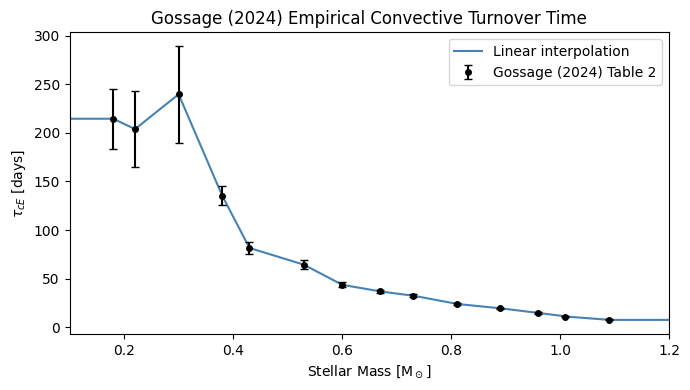

In [8]:
# τ_cE interpolation curve vs Gossage Table 2 points
mass_grid = np.linspace(0.10, 1.20, 500)
tau_grid  = tau_ce_interp(mass_grid)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(mass_grid, tau_grid, color='steelblue', lw=1.5, label='Linear interpolation')
ax.errorbar(
    gossage_table2['mass_msun'], gossage_table2['tau_ce'],
    yerr=gossage_table2['tau_ce_err'],
    fmt='o', color='black', ms=4, capsize=3, label='Gossage (2024) Table 2'
)
ax.set_xlabel(r'Stellar Mass [M$_\odot$]')
ax.set_ylabel(r'$\tau_{cE}$ [days]')
ax.set_title('Gossage (2024) Empirical Convective Turnover Time')
ax.legend()
ax.set_xlim(0.10, 1.20)
plt.tight_layout()
plt.show()

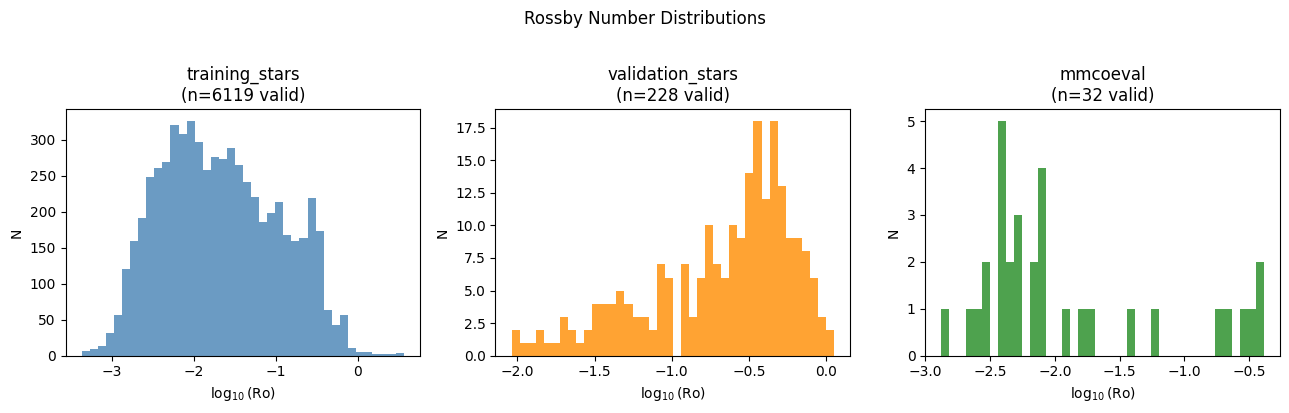

In [9]:
# Rossby number distributions per catalog
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=False)

datasets = [
    (training,   'training_stars',   'steelblue'),
    (validation, 'validation_stars', 'darkorange'),
    (mmcoeval,   'mmcoeval',         'forestgreen'),
]

for ax, (df, label, color) in zip(axes, datasets):
    ro = df['rossby_number'].dropna()
    ax.hist(np.log10(ro), bins=40, color=color, alpha=0.8, edgecolor='none')
    ax.set_xlabel(r'$\log_{10}$(Ro)')
    ax.set_ylabel('N')
    ax.set_title(f'{label}\n(n={len(ro)} valid)')

plt.suptitle('Rossby Number Distributions', y=1.02)
plt.tight_layout()
plt.show()

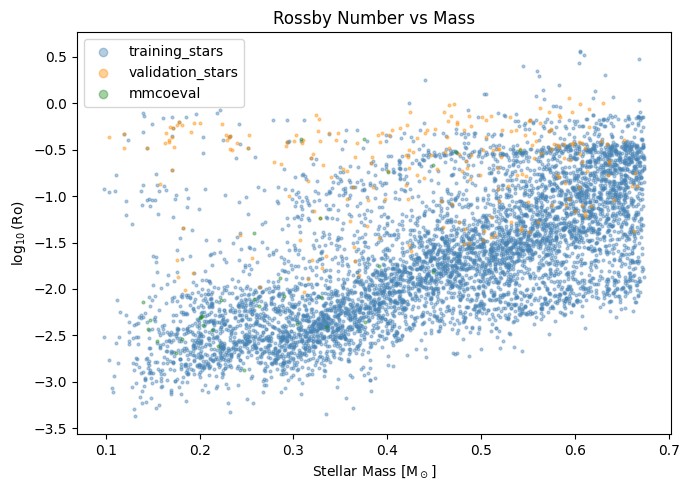

In [10]:
# Rossby number vs mass for all three catalogs
fig, ax = plt.subplots(figsize=(7, 5))

for df, label, color in datasets:
    valid = df[df['rossby_number'].notna()]
    ax.scatter(valid['mass_msun'], np.log10(valid['rossby_number']),
               s=4, alpha=0.4, color=color, label=label)

ax.set_xlabel(r'Stellar Mass [M$_\odot$]')
ax.set_ylabel(r'$\log_{10}$(Ro)')
ax.set_title('Rossby Number vs Mass')
ax.legend(markerscale=3)
plt.tight_layout()
plt.show()